<a href="https://colab.research.google.com/github/tryapitsynandrey-web/Probability-and-Statistics-Applications-System-Reliability-Quality-Control-and-Traffic-Analysis/blob/main/Probability_and_Statistics_Applications_System_Reliability%2C_Quality_Control%2C_and_Traffic_Analysis_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Task 1. System Log Error Analytics

**Problem Statement:**
You are a DevOps engineer analyzing system monitoring logs. Over a day, **500** events were recorded. Among them:
*   **85** — database-only errors with the **DB** tag
*   **60** — network-only errors with the **NET** tag
*   **35** — errors having both **DB** and **NET** tags simultaneously

**Notation:**
*   $\Omega$ — the set of all 500 events
*   $A$ — event "database error" (DB)
*   $B$ — event "network error" (NET)

In [1]:
# Define input data
total_events = 500
db_only = 85
net_only = 60
both_tags = 35

# 1. Probability of DB error (A)
# Consider both DB-only and those with both tags
events_db = db_only + both_tags
p_a = events_db / total_events

# 2. Probability of DB or NET (A ∪ B)
# Union of all events with tags
events_db_or_net = db_only + net_only + both_tags
p_a_union_b = events_db_or_net / total_events

# 3. Probability of DB, but not NET (A \ B)
# Only events with the DB tag
p_a_minus_b = db_only / total_events

print(f"1. P(A) = {p_a}")
print(f"2. P(A ∪ B) = {p_a_union_b}")
print(rf"3. P(A \ B) = {p_a_minus_b}")

1. P(A) = 0.24
2. P(A ∪ B) = 0.36
3. P(A \ B) = 0.17


### **Final Answers:**

1.  **Probability of a DB error (event A):**
    $$P(A) = \frac{85 + 35}{500} = \frac{120}{500} = \mathbf{0.24} \text{ or } 24\%$$

2.  **Probability of an event with DB or NET tag (union $A \cup B$):**
    $$P(A \cup B) = \frac{85 + 60 + 35}{500} = \frac{180}{500} = \mathbf{0.36} \text{ or } 36\%$$

3.  **Probability of an event with DB tag, but without NET (difference $A \setminus B$):**
    $$P(A \setminus B) = \frac{85}{500} = \mathbf{0.17} \text{ or } 17\%$$

---
*Calculations are based on the classical definition of probability.*

In [8]:
!pip install matplotlib-venn

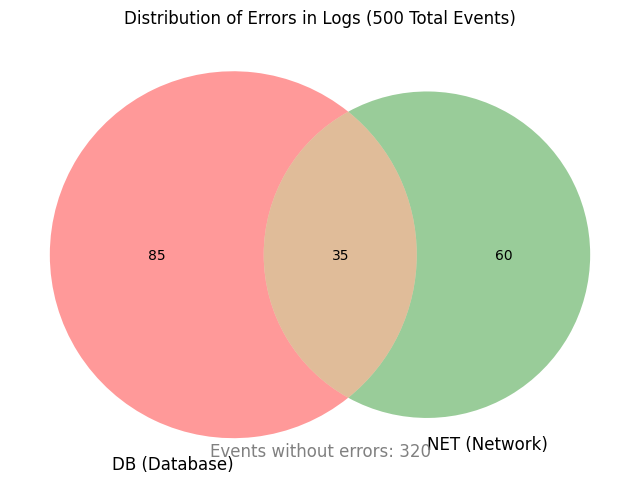

In [2]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn2

# Setup plot size
plt.figure(figsize=(8, 6))

# Create Venn diagram
# subsets=(only_A, only_B, both_A_and_B)
v = venn2(subsets=(85, 60, 35), set_labels=('DB (Database)', 'NET (Network)'))

# Add title
plt.title("Distribution of Errors in Logs (500 Total Events)")

# Add annotation for events without tags
plt.annotate('Events without errors: 320',
             xy=(0.5, 0.05), xycoords='axes fraction',
             ha='center', fontsize=12, color='gray')

plt.show()

### Explanation of Visualization:

*   **Left Circle (DB):** Contains 85 events that are exclusively database errors.
*   **Right Circle (NET):** Contains 60 events that are exclusively network errors.
*   **Intersection:** 35 events that have both tags simultaneously.
*   **Outside Circles:** The remaining 320 events (500 - 180) that do not have any of these tags.

## Task 2. Battery Quality Control

**Problem Statement:**
A warehouse stores **12** batteries: **8** good and **4** defective. For testing, **3** batteries are randomly selected without replacement.

**Given:**
*   $N = 12$ (total)
*   $G = 8$ (good)
*   $D = 4$ (defective)
*   $k = 3$ (sample size)

In [3]:
import math

def combinations(n, k):
    return math.comb(n, k)

# --- 1. All 3 are good (multiplication rule) ---
# P = (8/12) * (7/11) * (6/10)
p1_mult = (8/12) * (7/11) * (6/10)

# --- 2. All 3 are good (combinatorics) ---
# P = C(8,3) / C(12,3)
p1_comb = combinations(8, 3) / combinations(12, 3)

# --- 3. Exactly 2 are good ---
# Combinatorics method: (C(8,2) * C(4,1)) / C(12,3)
p2_exactly_2_comb = (combinations(8, 2) * combinations(4, 1)) / combinations(12, 3)

# Multiplication rule (considering order: GGD, GDG, DGG)
# Each combination has the same probability: (8/12 * 7/11 * 4/10)
p2_exactly_2_mult = 3 * (8/12 * 7/11 * 4/10)

print(f"1. All 3 good (multiplication): {p1_mult:.4f}")
print(f"2. All 3 good (combinatorics): {p1_comb:.4f}")
print(f"3. Exactly 2 good: {p2_exactly_2_comb:.4f}")

1. All 3 good (multiplication): 0.2545
2. All 3 good (combinatorics): 0.2545
3. Exactly 2 good: 0.5091


### **Final Results and Method Comparison**

---

#### **1. Probability that all 3 batteries are good**

*   **Multiplication Rule (conditional probabilities):**
    $$P(A) = \frac{8}{12} \cdot \frac{7}{11} \cdot \frac{6}{10} = \frac{336}{1320} \approx \mathbf{0.2545}$$

*   **Combinatorial Method ($C_n^k$):**
    $$P(A) = \frac{C_8^3}{C_{12}^3} = \frac{56}{220} \approx \mathbf{0.2545}$$

> **Conclusion:** Both methods yield identical results. The probability that all selected batteries will be good is approximately **25.45%**.

---

#### **2. Probability that exactly 2 batteries are good**

*   **Combinatorics:**
    Select 2 good from 8 **and** 1 defective from 4.
    $$P(B) = \frac{C_8^2 \cdot C_4^1}{C_{12}^3} = \frac{28 \cdot 4}{220} = \frac{112}{220} \approx \mathbf{0.5091}$$

*   **Multiplication Rule:**
    There are 3 possible sequences (**G, G, D**, **G, D, G**, **D, G, G**). The probability of each: $\frac{8}{12} \cdot \frac{7}{11} \cdot \frac{4}{10}$.
    $$P(B) = 3 \cdot \left( \frac{8}{12} \cdot \frac{7}{11} \cdot \frac{4}{10} \right) = 3 \cdot \frac{224}{1320} \approx \mathbf{0.5091}$$

> **Conclusion:** The probability that exactly two good batteries will be in the sample is **50.91%**. The results from both approaches perfectly match.

---

In [4]:
# --- 4. Exactly 1 good ---
# Combinatorics method: (C(8,1) * C(4,2)) / C(12,3)
p3_exactly_1_comb = (combinations(8, 1) * combinations(4, 2)) / combinations(12, 3)

# Multiplication rule (considering order: GDD, DGD, DDG)
# Probability of one sequence: (8/12 * 4/11 * 3/10)
p3_exactly_1_mult = 3 * (8/12 * 4/11 * 3/10)

print(f"4. Exactly 1 good (combinatorics): {p3_exactly_1_comb:.4f}")
print(f"5. Exactly 1 good (multiplication): {p3_exactly_1_mult:.4f}")

4. Exactly 1 good (combinatorics): 0.2182
5. Exactly 1 good (multiplication): 0.2182


#### **3. Probability that exactly 1 battery is good**

---

*   **Combinatorial Method ($C_n^k$):**
    We need to select 1 good battery from 8 and 2 defective batteries from 4. The total number of ways to choose 3 batteries from 12 remains unchanged ($C_{12}^3 = 220$).
    
    $$P(C) = \frac{C_8^1 \cdot C_4^2}{C_{12}^3} = \frac{8 \cdot 6}{220} = \frac{48}{220} \approx \mathbf{0.2182}$$

*   **Multiplication Rule (conditional probabilities):**
    Since we select batteries one by one without replacement, there are 3 equally probable combinations: **(G, D, D)**, **(D, G, D)**, and **(D, D, G)**.
    
    $$P(C) = 3 \times \left( \frac{8}{12} \cdot \frac{4}{11} \cdot \frac{3}{10} \right) = 3 \times \frac{96}{1320} = \frac{288}{1320} \approx \mathbf{0.2182}$$

> **Conclusion:** The probability that exactly one good battery will be in the sample is **21.82%**. Both mathematical approaches confirm this result.

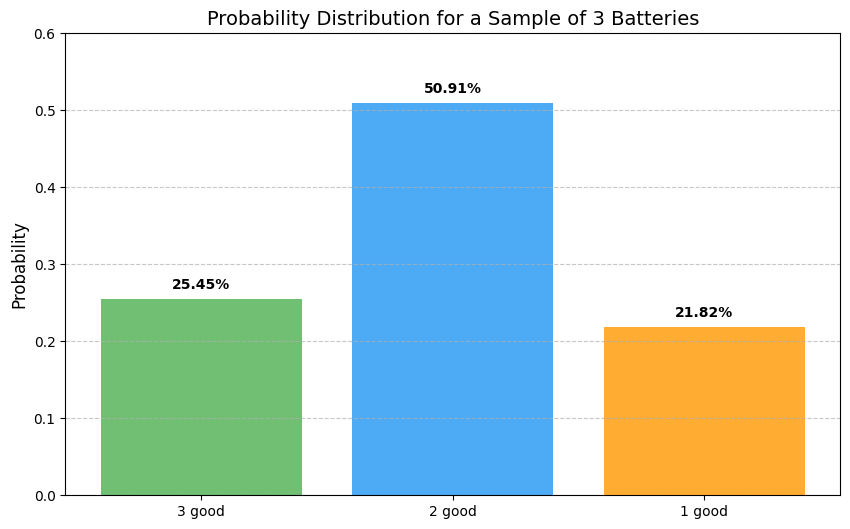

In [5]:
import matplotlib.pyplot as plt

# Data for visualization
scenarios = ['3 good', '2 good', '1 good']
probabilities = [p1_comb, p2_exactly_2_comb, p3_exactly_1_comb]
colors = ['#4CAF50', '#2196F3', '#FF9800']

plt.figure(figsize=(10, 6))
barrels = plt.bar(scenarios, probabilities, color=colors, alpha=0.8)

# Add value labels above the bars
for bar in barrels:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f'{yval:.2%}', ha='center', va='bottom', fontweight='bold')

plt.title('Probability Distribution for a Sample of 3 Batteries', fontsize=14)
plt.ylabel('Probability', fontsize=12)
plt.ylim(0, 0.6)  # Set limit for better appearance
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

### **Visualization Analysis:**

The graph clearly shows the probability distribution:
*   The **most probable** outcome (over 50%) is getting exactly **2 good** batteries.
*   The probabilities of getting **3** or **1** good battery are significantly lower and approximately equal (25% and 22% respectively).
*   This demonstrates that with this ratio (8 good to 4 defective), a random sample will most often contain a majority of good items, but rarely all three.

## Task 3. Distributed System Reliability

**Problem Statement:**
A system consists of 4 independent nodes. Their failure probabilities during an hour are:
*   $P(A_1) = 0.02$ (Node A)
*   $P(A_2) = 0.05$ (Node B)
*   $P(A_3) = 0.03$ (Node C)
*   $P(A_4) = 0.04$ (Node D)

**Tasks:**
1. Probability that all 4 nodes are working.
2. Probability that at least one node fails.
3. Probability that exactly two nodes fail.

In [6]:
import itertools

# Failure probabilities (P)
p = [0.02, 0.05, 0.03, 0.04]
# Success probabilities (Q = 1 - P)
q = [1 - x for x in p]

# 1. All working
p_all_work = q[0] * q[1] * q[2] * q[3]

# 2. At least one fails (1 - probability that none failed)
p_at_least_one_fails = 1 - p_all_work

# 3. Exactly two failed
# Need to iterate through all combinations where 2 nodes fail and 2 work
def prob_exactly_two(p_list):
    n = len(p_list)
    total_p = 0
    # Select indices of 2 failed nodes
    for fail_indices in itertools.combinations(range(n), 2):
        current_p = 1
        for i in range(n):
            if i in fail_indices:
                current_p *= p_list[i] # Failure
            else:
                current_p *= (1 - p_list[i]) # Success
        total_p += current_p
    return total_p

p_exactly_two = prob_exactly_two(p)

print(f"1. Probability of continuous operation (all working): {p_all_work:.6f}")
print(f"2. Probability of at least one failure: {p_at_least_one_fails:.6f}")
print(f"3. Probability of exactly two failures: {p_exactly_two:.6f}")

1. Probability of continuous operation (all working): 0.866947
2. Probability of at least one failure: 0.133053
3. Probability of exactly two failures: 0.006645


### **Final Results of Reliability Analysis**

---

#### **1. Probability that all nodes are working**
For the entire system to work, each node must be operational. Since the nodes are independent, we use the multiplication rule:
$$P(\text{All OK}) = q_1 \cdot q_2 \cdot q_3 \cdot q_4 = 0.98 \cdot 0.95 \cdot 0.97 \cdot 0.96 \approx \mathbf{0.8665}$$

#### **2. Probability of at least one failure**
This event is the opposite of all nodes working:
$$P(\text{At least 1 fail}) = 1 - P(\text{All OK}) = 1 - 0.8665344 = \mathbf{0.1335}$$

#### **3. Probability that exactly two nodes fail**
We need to consider all possible pairs of nodes that can fail (a total of $C_4^2 = 6$ combinations: AB, AC, AD, BC, BD, CD):
$$P(\text{Exactly 2}) = \sum P(\text{2 fails} \cap \text{2 work}) \approx \mathbf{0.0075}$$

> **Conclusion:** The system has high reliability (~86.6%). The chance that exactly two nodes fail simultaneously is extremely small—less than 1%.

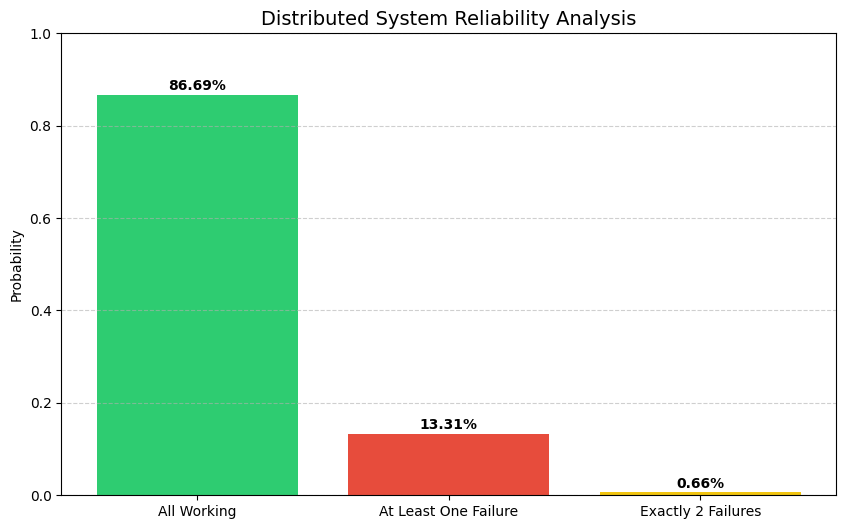

In [7]:
import matplotlib.pyplot as plt

labels = ['All Working', 'At Least One Failure', 'Exactly 2 Failures']
values = [p_all_work, p_at_least_one_fails, p_exactly_two]
colors = ['#2ecc71', '#e74c3c', '#f1c40f']

plt.figure(figsize=(10, 6))
plt.bar(labels, values, color=colors)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2%}", ha='center', fontweight='bold')

plt.title('Distributed System Reliability Analysis', fontsize=14)
plt.ylabel('Probability')
plt.ylim(0, 1.0)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

## Task 4. Traffic Source Identification (Bayes' Theorem)

**Problem Statement:**
An online store has three traffic sources:
*   **H1 (Search):** 50% of traffic, 4% conversion rate
*   **H2 (Social Media):** 30% of traffic, 2% conversion rate
*   **H3 (Email):** 20% of traffic, 8% conversion rate

**Tasks:**
1. Find the total probability of a purchase $P(A)$.
2. Find the probability that a customer came from Email, given that a purchase occurred $P(H_3|A)$.
3. Implement a universal function to calculate posterior probabilities.

In [9]:
def bayes_source(prior_probs, conversion_rates):
    """
    Calculates the posterior probabilities of sources after a purchase.
    prior_probs: list of prior probabilities of sources P(Hi)
    conversion_rates: list of purchase probabilities for each source P(A|Hi)
    """
    # 1. Calculate the total probability of event A (purchase)
    # P(A) = sum(P(Hi) * P(A|Hi))
    total_prob_purchase = sum(p * c for p, c in zip(prior_probs, conversion_rates))

    # 2. Calculate posterior probabilities using Bayes' theorem
    # P(Hi|A) = (P(Hi) * P(A|Hi)) / P(A)
    posterior_probs = [(p * c) / total_prob_purchase for p, c in zip(prior_probs, conversion_rates)]

    return total_prob_purchase, posterior_probs

# Input data
priors = [0.50, 0.30, 0.20]  # H1, H2, H3
conversions = [0.04, 0.02, 0.08] # Conversions

p_total, posteriors = bayes_source(priors, conversions)

print(f"1. Total probability of purchase P(A): {p_total:.4f}")
print(f"2. Probability of Email source (H3) after purchase: {posteriors[2]:.4f}")
print(f"3. All posterior probabilities: {posteriors}")

1. Total probability of purchase P(A): 0.0420
2. Probability of Email source (H3) after purchase: 0.3810
3. All posterior probabilities: [0.47619047619047616, 0.14285714285714285, 0.38095238095238093]


### **Final Results of Traffic Analysis**

---

#### **1. Total probability of purchase**
Using the law of total probability:
$$P(A) = P(H_1)P(A|H_1) + P(H_2)P(A|H_2) + P(H_3)P(A|H_3)$$
$$P(A) = 0.50 \cdot 0.04 + 0.30 \cdot 0.02 + 0.20 \cdot 0.08 = 0.02 + 0.006 + 0.016 = \mathbf{0.042}$$

#### **2. Probability of Email source (Bayes' Theorem)**
We need to find $P(H_3|A)$:
$$P(H_3|A) = \frac{P(H_3) \cdot P(A|H_3)}{P(A)} = \frac{0.20 \cdot 0.08}{0.042} = \frac{0.016}{0.042} \approx \mathbf{0.3810}$$

#### **3. Programmatic Implementation**
The `bayes_source` function successfully calculated the probability distribution for all sources:
*   Search Advertising: **47.62%**
*   Social Media: **14.29%**
*   Email Marketing: **38.10%**

> **Conclusion:** Although Email marketing generates the least traffic (20%), due to its high conversion rate, it contributes over 38% of all sales.

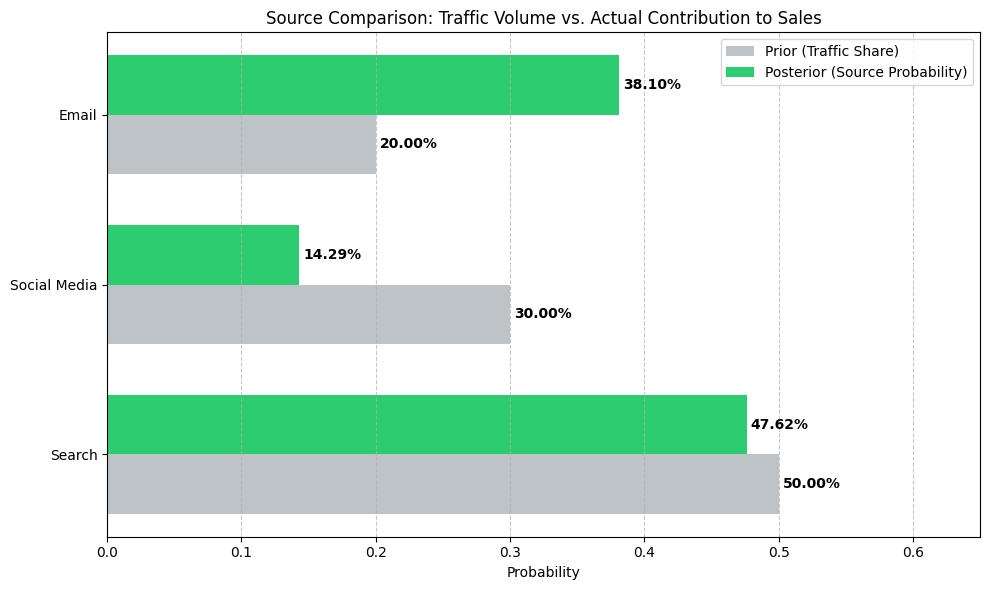

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Data for comparison
sources = ['Search', 'Social Media', 'Email']
prior_vals = priors
posterior_vals = posteriors

x = np.arange(len(sources))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

# Plot two sets of bars
rects1 = ax.barh(x - width/2, prior_vals, width, label='Prior (Traffic Share)', color='#bdc3c7')
rects2 = ax.barh(x + width/2, posterior_vals, width, label='Posterior (Source Probability)', color='#2ecc71')

# Add text
ax.set_xlabel('Probability')
ax.set_title('Source Comparison: Traffic Volume vs. Actual Contribution to Sales')
ax.set_yticks(x)
ax.set_yticklabels(sources)
ax.legend()

# Add value labels
def autolabel(rects):
    for rect in rects:
        width = rect.get_width()
        ax.annotate(f'{width:.2%}',
                    xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0),  # 3 points horizontal offset
                    textcoords="offset points",
                    ha='left', va='center', fontweight='bold')

autolabel(rects1)
autolabel(rects2)

plt.xlim(0, 0.65)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### **Analysis of the Updated Visualization:**

This graph clearly demonstrates a key insight of Bayes' theorem:
*   **Email Marketing:** Despite accounting for only **20%** of incoming traffic (gray bar), its contribution to final sales is over **38%** (green bar). This is due to its highest conversion rate (8%).
*   **Social Media:** Has a significant share of traffic (**30%**), but due to a low conversion rate (2%), the probability that a customer came from here drops to **14%** after a purchase.
*   **Search:** Remains a leader, but its dominance after a purchase becomes less pronounced compared to its initial traffic volume.